**Table of Contents**:
* **1. Problem Statement.**
* **2. Theoretical Concepts.**
* **3.Physical System.** 
* **4. Comuputational Approach.**
  * **Analytical.**
  * **FDM.**
  * **PINN.**
* **5.Analysis & Results.**

## **Problem Statement**



**The aim of this project is to simulate quantum tunneling through evolution of wave-function, and compare the result of calculation of transmission probability from Crank-Nicolson numerical method, and Physics Informed Neural Network with Analytical method.**

## **Introduction**

**Quantum Tunneling refers to the phenomenon where a particle with a lower energy as compared to barrier cross the barrier region. In the scenario of classical mechanics where a particle encounters a barrier or wall with higer energy then the energy of particle than particle is bounded/get reflected back, however in quantum mechanics when a particles encounters such a barrier they overcomes it and gets transmitted to the other side of barrier and therefore there is always a non zero probability where a particle can be found on the other side of a barrier. This phenomenon is called Quantum Tunnelling and probability of transmission is given by Transmission Probability(T).**

**This project calculates transmission probability by finding evolution of wavefunction, the evolution of wavefunction is governed by Schrondiger Equation.**

**Schrondiger Equation**:
***Schrondiger Equation governs the evolution of wavefunction, the wavefunction describes the state of quantum system and encodes the probabilites. The Time Dependent Schrondiger Equation in the form of Hamiltonian it is written as:***

#### $$-i\hbar\frac{\partial \psi}{\partial t} = \hat H \psi$$

where:

* $\boldsymbol{\psi}$ **is wavefunction which is a complex valued number that encodes different states of quantum system(particle) in terms of probabilities. The wavefunction needs to be operated by different linear operators to find about different states of particle(electon) such as it's position, momentum, energy, etc.**

* $\boldsymbol{\hat H}$ **is a Hamiltonian linear operator which defines the system's(particle's) energy in terms of Kinetic and Potential Energy, the Ham$$iltonian operates on wavefunction.**

* $\boldsymbol{i}$, $\boldsymbol{\hbar}$ , $\boldsymbol{t}$ are imaginary number, reduced planck constant and time.

**Hamiltonian in the form of laplacian can also be written as**
$$\hat H = \frac{h}{2m}\nabla^2 + V(X,Y) $$
$$\nabla^2 = \Bigg[\frac{\partial\psi^2}{\partial x^2}+\frac{\partial\psi^2}{\partial y^2}\Bigg] $$

  

## **Designing Physical system**

***The initial wavefunction for the physical system is a Gaussian Wavefunction:***

$$
\psi_0(x, y) = \frac{1}{\sqrt{\mathcal{N}}} \exp\Bigg[ -\frac{(x - x_0)^2}{2\sigma_x^2} - \frac{(y - y_0)^2}{2\sigma_y^2} + k_{x0} x + k_{y0} y )\Bigg]
$$

where:
* $x_0$  and $y_0$  are the initial positions,
* $\sigma_x$,  $\sigma_y$  are the spatial widths of the Gaussian,
* $k_{x0}$ and  $k_{y0}$ represents the initial wave vector components,
* $\mathcal{N}$  is the normalization constant chosen such that:

***The conservation law states that the total probability of finding the particle in the spatial domain is always equals to 1:***
$$
\int |\psi_0(x, y)|^2 \, dx \, dy = 1
$$


**Energy Landscape**:
***The potential V(x) represents a square barrier centered at  x = 0  and is defined as:***

$$
V(x) =
\begin{cases}
V_0, & \text{if } -a/2 < x < a/2 \\
0, & \text{otherwise}
\end{cases}
$$

where:
* $V_0 $ is the height of the potential barrier,
* $a$ is the total width of the barrier, centered at  x = 0.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import factorized

# Constants
hbar = 1.0545718e-34
m_e = 9.10938356e-31
wavelength = 20e-9
k0 = 2 * np.pi / wavelength

# Grid
Lx, Ly = 1e-6, 1e-6
Nx, Ny = 512, 512
dx, dy = Lx / Nx, Ly / Ny
x = np.linspace(-Lx / 2, Lx / 2, Nx)
y = np.linspace(-Ly / 2, Ly / 2, Ny)
X, Y = np.meshgrid(x, y)

# Time
dt = 3e-14
Nt = 501

# Barrier parameters
barrier_width = 1e-8  # Width of the square barrier (meters)
barrier_height = 1.05 * hbar**2 * k0**2 / (2 * m_e)  # Height of the barrier (Joules)


# Initial Gaussian wave packet
sigma_x = sigma_y = 60e-9
x0, y0 = -2e-7, 0
kx0, ky0 = k0, 0
psi0 = np.exp(-(X - x0) ** 2 / (2 * sigma_x ** 2)) * np.exp(-(Y - y0) ** 2 / (2 * sigma_y ** 2))
psi0 = psi0.astype(np.complex128)
psi0 *= np.exp(1j * (kx0 * X + ky0 * Y))
psi0 /= np.sqrt(np.sum(np.abs(psi0) ** 2))

# Potential (square barrier in center)
V = np.zeros_like(X)
V[np.abs(X) < 1e-8 / 2] = 1.05 * hbar**2 * k0**2 / (2 * m_e)
V_vector = V.flatten()

## **Crank Nicolson Method**

**Crank Nicolson Method is used to numerically solve partial differential equations, this method is unconditionally stable however computationally expensive as it requires to solve a linear equation for each-timestep.**
**This method uses the average of Euler's implicit and explicit method and the numerical result(time evolution of a quantity- Wavefunction) is acheived numerically by solving the linear system for each next time-step($\psi_{n+1}$) and is given by.**
$$(I - \frac{-i \Delta t}{2 \hbar} H)\psi_{n+1} = (I - \frac{-i \Delta t}{2 \hbar} H)\psi_{n}$$

here
* I is Indentity Matrix
* $H$ is discretized Hamiltonian Matrix
* $\hbar$ is reduced planck constant
* $i$,$\Delta t$,$\psi$ are imaginary number, reduced planck constant, and change in time.

***The implementation steps of Crank Nicolson is given below:***

1. *The spatial and time variable such as **X, Y, T**; and the $\hat H$ operator are continous,the first step here is to discretize them.
Therefore,let X be discretized into $X =\sum_{i=1}^{N}\Delta x$ and Y be discretized into $X =\sum_{j=1}^{N}\Delta y$ and T be discretized into $T =\sum_{k=1}^{N}\Delta t$, and Hamiltonian $\hat H$ be discretized into*:

$$ \nabla^2 \psi_{i,j} \approx \frac{\psi_{i+1,j} - 2\psi_{i,j} + \psi_{i-1,j}}{\Delta x^2}+ \frac{\psi_{i,j+1} - 2\psi_{i,j} + \psi_{i,j-1}}{\Delta y^2}$$

therefore $$H = \frac{h}{2m} \nabla^2 \psi_{i,j} + V(X,Y)$$ 

2. *From Time Dependent Schrondiger Equation, the time derivative can be approximated using mid-point rule:*
   $$\frac{\partial \psi(X,Y,T)}{\partial t} = \frac{-i}{\hbar} \hat H \psi$$

   $$\frac{\partial \psi}{\partial t}= \frac{\psi_{n+1} - \psi_{n}}{\Delta t}$$

3. *Implementing Implicit and Explicit Euler expression for $\psi_{n+1}$ will yield-*
   
   for forward euler expression:
   $$\frac{\psi_{n+1} - \psi_{n}}{\Delta t} = \frac{-i}{\hbar} H \psi_{n}$$
   
   for backward euler expression:
   $$\frac{\psi_{n+1} - \psi_{n}}{\Delta t} = \frac{-i}{\hbar}\ H \psi_{n+1}$$

   rearranging this term and averaging both implicit and explicit method will yeild-
   $${\psi_{n+1} - \psi_{n}} = \frac{-i \Delta t}{2 \hbar}\hat H \psi_{n} + \frac{-i \Delta t}{2 \hbar} \hat H \psi_{n+1}$$

   rearranging $psi_{n+1}$ on the left-hand side and $psi_n$ on the right-   
   $$\psi_{n+1} - \frac{-i \Delta t}{2 \hbar}\hat H \psi_{n+1} = \psi_{n} + \frac{-i \Delta t}{2 \hbar}\hat H \psi_{n}$$

   The Cranck Nicolson will solve the following linear system for right hand side to produce $psi_{n+1}$ for each time-step-
   
   $$(I - \frac{-i \Delta t}{2 \hbar}\hat H)\psi_{n+1} = (I - \frac{-i \Delta t}{2 \hbar}\hat H)\psi_{n}$$

And this following linear system is solved by using Kronickle Sum, which is helpful to computes larger matrices.

/home/vipin24/anaconda3/envs/comp_physics/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


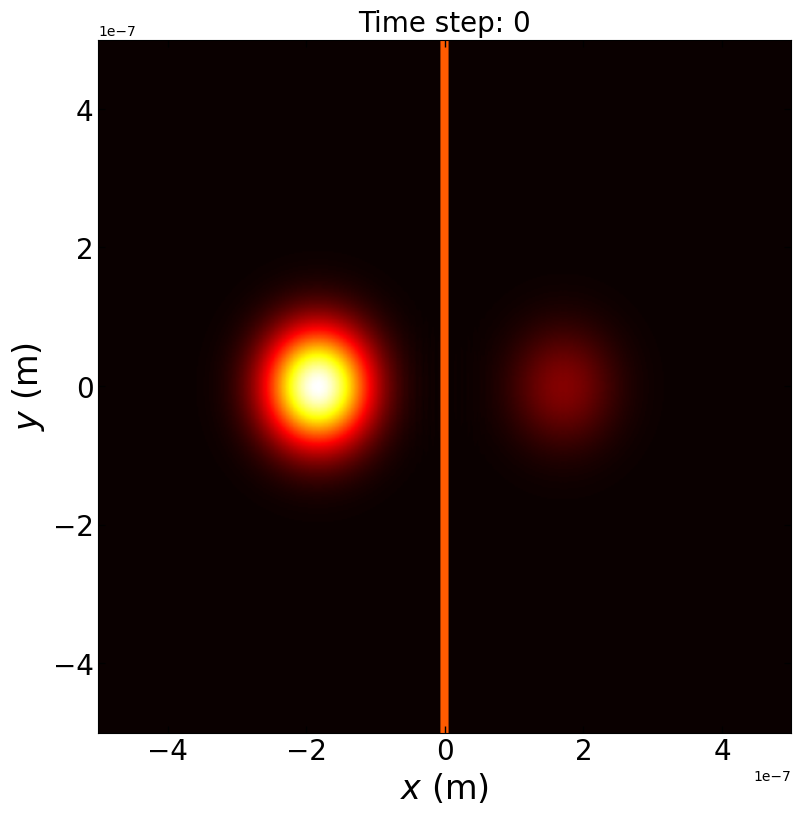

In [3]:
# Laplacian in 2D (finite difference)
main_diag_x = -2.0 * np.ones(Nx)
off_diag_x = np.ones(Nx - 1)
laplacian_x = diags([off_diag_x, main_diag_x, off_diag_x], [-1, 0, 1]) / dx**2

main_diag_y = -2.0 * np.ones(Ny)
off_diag_y = np.ones(Ny - 1)
laplacian_y = diags([off_diag_y, main_diag_y, off_diag_y], [-1, 0, 1]) / dy**2

Ix = identity(Nx)
Iy = identity(Ny)
Laplacian_2D = kron(Iy, laplacian_x) + kron(laplacian_y, Ix)

# Hamiltonian and Crank-Nicolson matrices
H = -(hbar**2 / (2 * m_e)) * Laplacian_2D + diags(V_vector, 0)
I_big = identity(Nx * Ny)
A = I_big + 1j * dt * H / (2 * hbar)
B = I_big - 1j * dt * H / (2 * hbar)

# Use LU factorized solver
solve_A = factorized(A)

# Time evolution
psi_n = psi0.flatten()

# Setup plot
fig, ax = plt.subplots(figsize=(16, 9))

def update(t):
    global psi_n
    b = B @ psi_n
    psi_n = solve_A(b)
    psi = psi_n.reshape((Ny, Nx))

    # Visualization
    ax.clear()
    ax.set_xlabel(r'$x$ (m)', fontsize=24)
    ax.set_ylabel(r'$y$ (m)', fontsize=24)
    ax.tick_params(which="major", axis="both", direction="in", top=True, right=True, length=5, width=1, labelsize=20)
    normalized_psi = np.abs(psi) ** 2 / np.max(np.abs(psi) ** 2)
    normalized_V = V / np.max(V)
    combined = normalized_psi + 0.5 * normalized_V
    im = ax.imshow(combined, extent=(-Lx / 2, Lx / 2, -Ly / 2, Ly / 2), cmap='hot', animated=True)
    ax.set_title(f'Time step: {t}', fontsize=20)
    return [im]

# Animate directly using the update function
VVV = animation.FuncAnimation(fig, update, frames=Nt, repeat=False)
VVV.save('quantum_optimized.mp4', writer='ffmpeg', fps=20)

# Run the evolution for Nt time steps
for t in range(Nt):
    update(t)

In [4]:
# Transmission probability Calculation using Crack-Nilson
barrier_position = barrier_width / 2  
transmitted_mask = X > barrier_position

psi =  psi_n.reshape((Ny,Nx))

transmitted_prob = np.sum(np.abs(psi[transmitted_mask]) ** 2) * dx * dy
total_prob = np.sum(np.abs(psi) ** 2) * dx * dy
Crack_Transmission_Probability = transmitted_prob / total_prob
Crack_Transmission_Probability

0.15281296762931024

## **Analytical Method**

*# Analytical Transmission Probability:
The analytical transmission is calculated directly from schrondiger equation and it given by

The energy of the particle is:
$$ E = \frac{\hbar^2 k_0^2}{2 m_e}$$

If \( E < V_0 \), then:
$$\alpha = \frac{\sqrt{2 m_e (V_0 - E)}}{\hbar}$$


And the analytical transmission probability is:
$$ T_{\text{analytical}} = \frac{1}{1 + \left( \frac{V_0^2}{4 E (V_0 - E)} \right) \sinh^2(\alpha a)}$$

If \( E = V_0 \), the transmission is:
$$T_{\text{analytical}} = 1$$


In [5]:
# Analytical Transmission Probability Calculation
E = (hbar**2 * k0**2) / (2 * m_e)

if E < barrier_height:
    alpha = np.sqrt(2 * m_e * (barrier_height - E)) / hbar
    T_analytical = 1 / (1 + (barrier_height**2 / (4 * E * (barrier_height - E))) * np.sinh(alpha * barrier_width)**2)
else:
    T_analytical = 1.0  # If E >= V_0, classical transmission occurs

T_analytical

0.2381924329202557

## **Physics Informed Neural Network**

***Physics Informed Neural Network is a type of neural network that are widely used in solving physics problems such as Heat Equation and Time Dependent Schrodinger Equation,etc as these equation involves partial differential equations , the PINN embeds the underlying physical laws into their training process in the form of Loss Function. This approach ensures that prediction of Neural Network is consistent with underlying physics.***

***Solving PINN requires several components such as:***
* ***Defining Neural Network Architecture***
* ***Defining Loss Function***
* ***Training Process***

### 2. Loss Function 

***The goal of loss function in PINN is to enforce physical laws into Neural Network such as Schrodinger Equation through residual loss function, and to make Neural Network  obey other physical constraints such as initial conditions(Initial Wavefunction at time t =0) and boundary conditions(homogenous Dirchelt's boundary condition) of the given problem by incorporating initial loss and boundary loss function. Additionally few others loss function could be added to enforce the PINN to obey conservation laws i.e probability conservation laws.***


***There are four loss functions that I have used here:***

* a. ***Initial loss.***
* b. ***Boundaray loss.***
* c. ***Residual loss.***
* d. ***Probability conservation loss.***

  <!-- 3. **Loss:** The PDE loss term is typically the mean squared error (MSE) of the residual across all collocation points.


#### b. Initial Condition Loss- This loss enforce that the prediction from Neural Network at time t = 0 should match the initial condition of the problem in my case Gaussian wave packet,

- **Computation:** Compare the predicted wavefunction $\psi(x,y,0)$  with the defined initial condition. The error is computed using mean square error(MSE) over the spatial domain. -->


### **Loss-Functions**

### A. PDE Residual Loss:
 ***PDE loss ensures the predicted solution from Neural Network should satisfy the Schrodinger Equation, the pde residual to calculate the PDE Residual loss function is formed by taking the time derivative and second spatial derivative of the predicted output([$\psi_{Real}$,$\psi_{Imaginary}$\]) and substituting into Time Dependent Schrondiger Equation. Then the residual 'R' is evalated on set of collocation points on the entire domain.*** 
 

     
 $$R(x,y,t) = \frac{\partial \psi(x,y,t)}{\partial t}  - \Bigg[\frac{\partial^2 \psi(x,y,t)}{\partial x^2} + \frac{\partial^2 \psi(x,y,t))}{\partial y^2}\Bigg]\psi + V(x,y)$$

***The residial loss is calculated by taking mean square error of the residuals from predicted value and the actual value across all the collocation points, the PINN model obeys the governing laws of physics well if R(x,y,t) is closer to zero.***

### B.Initial Loss:
***The Initial loss ensures that the Neural Network satisfy the Initial state such as Initial Wavefunction\[$\psi(x,y,0)$\] at time t = 0 for the set of collocation points sampled in the entire domain. The predicted [$\hat \psi(x,y,0)$\] is compared with the actual \[$\psi(x,y,0)$\] using MSE to compute the initial loss, and determining the difference between predicted and actual wavefunction at time t = 0 helps to satisy the inital condition.***

***For this given problem the loss function computes numerical error in Neural Network in predicting Gaussain Wavepacket, as the initial state of wavefunction at time = 0 is Gaussain Wavefunction.***

***The initial loss for real and imaginary part of wavefunction is calculted by:***
$$L_{ic} = \frac{1}{N}\sum_{i=1}^{N}\Bigg[[(\hat \psi_{r}(x_i,y_i,0)-\psi_{0r}(x_i,y_i,0)]+ [(\hat \psi_{im}(x_i,y_i,0)-\psi_{0im}(x_i,yi,0)]\Bigg] $$



### C. Boundary Loss:
***The Boundary Condtion loss ensures that the predicted wavefunction from Neural Network should satisfy the boundary condition'homogenous boundary condition" in this problem for the given $\psi(x,y,t)$ for the collocated points sampled at the edges of spatial domain. Similar to initial condtion loss, here the predicted wavefunction \[$\hat \psi(x,y,t)$\] is compared with the actual \[$\psi_{x,y,t}$\] using MSE to compute boundary condition loss and determining the difference in boundary condition at the edges helps to satisfy the boundary conditions.***
***For this problem the $\psi(x,y,t)$ is set to be zero around all the edges and boundary loss computes numerical error in Neural Network in satisying the boun*** 

* ***The Boundary Condition loss for real and imaginary part of wavefunction is given by:***
  $$L_{bc} = \frac{1}{N}\sum_{i=1}^{N}\Bigg[[(\hat \psi_{r}(x_i,y_i,t)-\psi_{r}(x_i,y_i,t)]+ [(\hat\psi_{im}(x_i,y_i,t)-\psi_{im}(x_i,yi,t)]\Bigg] $$



In [6]:
import torch
import torch.nn as nn

In [7]:
import torch
import torch.nn as nn

class PINN_TDSE_2D(nn.Module):
    def __init__(self, layers):
        super(PINN_TDSE_2D, self).__init__()
        self.activation = torch.sin  # Sin works better for wavefunctions
        self.linears = nn.ModuleList()

        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        # Introduce skip connections for better gradient flow
        self.skip = nn.Linear(layers[0], layers[-1])

    def forward(self, xyt):
        output = xyt
        for i in range(len(self.linears) - 1):
            output = self.activation(self.linears[i](output))
        
        output = self.linears[-1](output) + self.skip(xyt)  # Skip connection
        return output

# Define model
layers = [3, 50, 50, 50, 2] 
model = PINN_TDSE_2D(layers)

# making changes
def V_crack_nilson(x, y):
    # Convert x and y to numpy for easier thresholding
    V0 = 1.05 * hbar**2 * k0**2 / (2 * m_e)  # matches Crack-Nilson
    width_x = 1e-8  # same as Crack-Nilson width
    V = torch.where(
        (torch.abs(x) < width_x/2),
        V0 * torch.ones_like(x),
        torch.zeros_like(x)
    )
    return V

In [8]:
def pde_loss(model, xyt, V_func, hbar=1.0545718e-34, m=9.10938356e-31):
    xyt.requires_grad_(True)
    psi = model(xyt)
    psi_r = psi[:, 0:1]
    psi_i = psi[:, 1:2]

    # Time derivatives
    psi_r_t = torch.autograd.grad(psi_r, xyt, grad_outputs=torch.ones_like(psi_r), retain_graph=True, create_graph=True)[0][:, 2:3]
    psi_i_t = torch.autograd.grad(psi_i, xyt, grad_outputs=torch.ones_like(psi_i), retain_graph=True, create_graph=True)[0][:, 2:3]

    # Second spatial derivatives
    psi_r_x = torch.autograd.grad(psi_r, xyt, grad_outputs=torch.ones_like(psi_r), retain_graph=True, create_graph=True)[0][:, 0:1]
    psi_r_xx = torch.autograd.grad(psi_r_x, xyt, grad_outputs=torch.ones_like(psi_r_x), retain_graph=True, create_graph=True)[0][:, 0:1]

    psi_i_x = torch.autograd.grad(psi_i, xyt, grad_outputs=torch.ones_like(psi_i), retain_graph=True, create_graph=True)[0][:, 0:1]
    psi_i_xx = torch.autograd.grad(psi_i_x, xyt, grad_outputs=torch.ones_like(psi_i_x), retain_graph=True, create_graph=True)[0][:, 0:1]

    # Compute y-derivatives for psi_r
    psi_r_y = torch.autograd.grad(psi_r, xyt, grad_outputs=torch.ones_like(psi_r), 
                                retain_graph=True, create_graph=True)[0][:, 1:2]
    psi_r_yy = torch.autograd.grad(psi_r_y, xyt, grad_outputs=torch.ones_like(psi_r_y), 
                                 retain_graph=True, create_graph=True)[0][:, 1:2]

    # Compute y-derivatives for psi_i
    psi_i_y = torch.autograd.grad(psi_i, xyt, grad_outputs=torch.ones_like(psi_i), 
                                retain_graph=True, create_graph=True)[0][:, 1:2]
    psi_i_yy = torch.autograd.grad(psi_i_y, xyt, grad_outputs=torch.ones_like(psi_i_y), 
                                 retain_graph=True, create_graph=True)[0][:, 1:2]

    V = V_func(xyt[:, 0:1], xyt[:, 1:2])


    # Calculating laplcian for real and imaginary part of wavefunction
    laplacian_psi_r = psi_r_xx + psi_r_yy
    laplacian_psi_i = psi_i_xx + psi_i_yy

    
     # computing PDE residual here
    res_r = hbar * psi_i_t + (hbar**2) / (2 * m) * laplacian_psi_r - V * psi_r
    res_i = -hbar * psi_r_t + (hbar**2) / (2 * m) * laplacian_psi_i - V * psi_i

    # Add gradient penalty to force learning
    grad_penalty = torch.mean(torch.abs(psi_r_xx) + torch.abs(psi_i_xx) + torch.abs(psi_r_t) + torch.abs(psi_i_t))

    return torch.mean(res_r**2) + torch.mean(res_i**2) + 0.1 * grad_penalty

# Separate real and imaginary parts
psi0_r_np = np.real(psi0)
psi0_i_np = np.imag(psi0)

# Convert to torch tensors if needed
psi0_r = torch.tensor(psi0_r_np, dtype=torch.float32)
psi0_i = torch.tensor(psi0_i_np, dtype=torch.float32)

psi0_r = psi0_r.view(-1,1)
psi0_i = psi0_i.view(-1,1)

def initial_condition_loss(model, x_init, y_init, psi0_r, psi0_i):
    t0 = torch.zeros_like(x_init)
    xyt0 = torch.cat([x_init, y_init, t0], dim=1)
    psi_pred = model(xyt0)
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]

    # Separate losses for real and imaginary parts
    loss_real = torch.mean((psi_r_pred - psi0_r) ** 2)
    loss_imag = torch.mean((psi_i_pred - psi0_i) ** 2)

    # Enforce correct wave packet normalization
    norm_pred = torch.mean(psi_r_pred**2 + psi_i_pred**2)
    norm_true = torch.mean(psi0_r**2 + psi0_i**2)
    loss_norm = (norm_pred - norm_true) ** 2

    return loss_real + loss_imag + 0.1 * loss_norm  # Small weight on normalization

def boundary_condition_loss(model, x_bc, y_bc, t_bc):
    xyt_bc = torch.cat([x_bc, y_bc, t_bc], dim=1)
    psi_pred = model(xyt_bc)
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]
    loss_bc = torch.mean(psi_r_pred**2 + psi_i_pred**2)
    return loss_bc

def probability_conservation_loss(model, xyt_points, xyt0_points):
    psi_pred = model(xyt_points)
    psi0_pred = model(xyt0_points)

    rho_pred = psi_pred[:, 0:1]**2 + psi_pred[:, 1:2]**2
    rho0_pred = psi0_pred[:, 0:1]**2 + psi0_pred[:, 1:2]**2

    # Compute total probability
    dx = (torch.max(xyt_points[:, 0]) - torch.min(xyt_points[:, 0])) / xyt_points.shape[0]
    dy = (torch.max(xyt_points[:, 1]) - torch.min(xyt_points[:, 1])) / xyt_points.shape[1]

    prob_pred = torch.sum(rho_pred) * dx * dy
    prob0_pred = torch.sum(rho0_pred) * dx * dy

    # ✅ Force gradient contribution by using `.detach()` on denominator only
    eps = 1e-8
    loss_prob = ((prob_pred - prob0_pred) / (prob0_pred.detach() + eps))**2 * 1000

    return loss_prob


**The collocated points is sampled across all the domain to satisfy given initial and boundary conditions, the points are also sampled using adpative sampling technqiue and density is increased around post barrier region. The model is optimized by calculating the total loss function and minimizing it to satisfy all the physical constrained in the model.**

In [9]:
import torch.optim as optim

#  Sample Training Points
x_min, x_max = -0.5e-6, 0.5e-6
y_min, y_max = -0.5e-6, 0.5e-6
t_min, t_max = 0.0, 2e-14

#  Define Barrier Properties
barrier_x = 0.0  
width_x = 1e-8  

# Use the same grid as Crack-Nilson:
X_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1,1)
Y_flat = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1,1)

x_init = X_flat
y_init = Y_flat

psi0_r = torch.ones(x_init.shape)
psi0_i = torch.zeros(x_init.shape)


def generate_static_collocation_points(N_full=10000, N_post=5000):
    """
    Generate collocation points across the full domain plus extra points
    in the post-barrier region (x > barrier_x).
    """
    # Full domain collocation
    x_full = torch.rand(N_full, 1) * (x_max - x_min) + x_min
    y_full = torch.rand(N_full, 1) * (y_max - y_min) + y_min
    t_full = torch.rand(N_full, 1) * (t_max - t_min) + t_min
    colloc_full = torch.cat([x_full, y_full, t_full], dim=1)
    
    # Extra collocation in the post-barrier region
    x_post = torch.rand(N_post, 1) * (x_max - barrier_x) + barrier_x
    y_post = torch.rand(N_post, 1) * (y_max - y_min) + y_min
    t_post = torch.rand(N_post, 1) * (t_max - t_min) + t_min
    colloc_post = torch.cat([x_post, y_post, t_post], dim=1)
    
    # Merge and enable gradient tracking
    collocation_points = torch.cat([colloc_full, colloc_post], dim=0)
    collocation_points.requires_grad_(True)
    
    return collocation_points

# Generate initial static collocation points.
xyt_colloc_current = generate_static_collocation_points()


# 2. Adaptive Sampling

def adaptive_sampling(model, grid_size=200, error_threshold=0.01, N_new=2000):
    
    # Create a structured grid for x and y; using a fixed time at the midpoint.
    x_grid = torch.linspace(x_min, x_max, grid_size).view(-1, 1)
    y_grid = torch.linspace(y_min, y_max, grid_size).view(-1, 1)
    t_fixed = (t_min + t_max) / 2.0

    # Creating a meshgrid for (x, y)
    X, Y = torch.meshgrid(x_grid.squeeze(), y_grid.squeeze(), indexing='ij')
    X_flat = X.reshape(-1, 1)
    Y_flat = Y.reshape(-1, 1)
    T_fixed = torch.full((X_flat.shape[0], 1), t_fixed)

    eval_points = torch.cat([X_flat, Y_flat, T_fixed], dim=1)
    eval_points.requires_grad_(True)

    
# --------------------------------------------------
# 5. Generate Boundary Condition Collocation Points 
# --------------------------------------------------
N_boundary_lr = 1000  # for left/right edges
N_boundary_tb = 1000  # for top/bottom edges

# Left and Right Edges
x_bc_lr = torch.cat([
    torch.full((N_boundary_lr // 2, 1), x_min),
    torch.full((N_boundary_lr // 2, 1), x_max)
], dim=0)
y_bc_lr = torch.rand(N_boundary_lr, 1) * (y_max - y_min) + y_min
t_bc_lr = torch.rand(N_boundary_lr, 1) * (t_max - t_min) + t_min

# Top and Bottom Edges
x_bc_tb = torch.linspace(x_min, x_max, N_boundary_tb).view(-1, 1)
y_bc_tb = torch.cat([
    torch.full((N_boundary_tb // 2, 1), y_min),
    torch.full((N_boundary_tb // 2, 1), y_max)
], dim=0)
t_bc_tb = torch.rand(N_boundary_tb, 1) * (t_max - t_min) + t_min

# Merge Boundary Points
x_bc = torch.cat([x_bc_lr, x_bc_tb], dim=0)
y_bc = torch.cat([y_bc_lr, y_bc_tb], dim=0)
t_bc = torch.cat([t_bc_lr, t_bc_tb], dim=0)

# 6. Training Loop with Adaptive Sampling

optimizer = optim.Adam(model.parameters(), lr=5e-3)
num_epochs = 1000


lambda_pde = 1000
lambda_ic = 10
lambda_bc = 10
lambda_prob = 100

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    loss_pde = pde_loss(model, xyt_colloc_current, V_func=V_crack_nilson)
    loss_ic  = initial_condition_loss(model, x_init, y_init, psi0_r, psi0_i)
    loss_bc  = boundary_condition_loss(model, x_bc, y_bc, t_bc)
    loss_prob = probability_conservation_loss(model, xyt_colloc_current,
                                               torch.cat([x_init, y_init, torch.zeros_like(x_init)], dim=1))
    
    total_loss = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc + lambda_prob * loss_prob
    total_loss.backward()
    optimizer.step()
    
    # if epoch % 100 == 0:
    #     print(f"Epoch {epoch} | Total Loss: {total_loss.item():.6f}")
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Total Loss: {total_loss.item():.6f} | PDE: {loss_pde.item():.6f} | IC: {loss_ic.item():.6f} | BC: {loss_bc.item():.6f} | Prob: {loss_prob.item():.6f}")
    
    # Every 200 epochs, add new collocation points adaptively
    if epoch % 200 == 0 and epoch > 0:
        new_points = adaptive_sampling(model, grid_size=200, error_threshold=0.01, N_new=2000)
        if new_points is not None:
            xyt_colloc_current = torch.cat([xyt_colloc_current, new_points], dim=0)
            print(f"Adaptive sampling: new collocation points added. Total now: {xyt_colloc_current.shape[0]}")

Epoch 0 | Total Loss: 80.033798 | PDE: 0.057090 | IC: 1.852779 | BC: 0.441010 | Prob: 0.000059
Epoch 100 | Total Loss: 9.092223 | PDE: 0.003550 | IC: 0.248931 | BC: 0.305028 | Prob: 0.000028
Epoch 200 | Total Loss: 8.136764 | PDE: 0.002586 | IC: 0.236561 | BC: 0.318256 | Prob: 0.000031
Epoch 300 | Total Loss: 6.988806 | PDE: 0.001452 | IC: 0.260292 | BC: 0.293157 | Prob: 0.000026
Epoch 400 | Total Loss: 6.576486 | PDE: 0.001040 | IC: 0.266214 | BC: 0.287176 | Prob: 0.000025
Epoch 500 | Total Loss: 8.828360 | PDE: 0.003286 | IC: 0.281306 | BC: 0.272741 | Prob: 0.000022
Epoch 600 | Total Loss: 6.357242 | PDE: 0.000815 | IC: 0.246629 | BC: 0.307265 | Prob: 0.000028
Epoch 700 | Total Loss: 7.244578 | PDE: 0.001704 | IC: 0.248732 | BC: 0.305040 | Prob: 0.000028
Epoch 800 | Total Loss: 7.558016 | PDE: 0.002010 | IC: 0.285355 | BC: 0.269225 | Prob: 0.000022
Epoch 900 | Total Loss: 7.930916 | PDE: 0.002383 | IC: 0.288169 | BC: 0.266440 | Prob: 0.000021


### Calculation of Transmission Probability:

The tranmission is calculated by using following steps:

* *Wavefunction Predicton* The NN predicts the real and imaginary part of wavefunction at the final time.
  
* Total Probability(Probability density integration) is calculted using sum of square of real and imaginary part of wavefunction:
  $$\rho(x,y) = |\psi(x, y)|^2 = \psi_r^2(x, y) + \psi_{im}^2(x, y)$$

* The probability density is integrated over this post-barrier region to compute the transmission probability.
  $$P_{\text{trans}} = \int_{x_b}^{\infty} \int_{-\infty}^{\infty} \rho(x, y)\, dx\, dy$$

$$T = \frac{P_{trans}}{P_{total}}$$

In [10]:
import torch
import numpy as np

# Predict the wavefunction at final time
def predict_wavefunction(model, x_vals, y_vals, t_final):
    X, Y = torch.meshgrid(x_vals, y_vals, indexing='ij')
    T = torch.ones_like(X) * t_final

    xyt_points = torch.cat([
        X.reshape(-1, 1),
        Y.reshape(-1, 1),
        T.reshape(-1, 1)
    ], dim=1)

    psi_pred = model(xyt_points)
    psi_r = psi_pred[:, 0].detach().numpy().reshape(X.shape)
    psi_i = psi_pred[:, 1].detach().numpy().reshape(X.shape)

    return psi_r, psi_i, X.numpy(), Y.numpy()

# Compute probability density from wavefunction
def compute_probability_density(psi_r, psi_i):
    return psi_r ** 2 + psi_i ** 2

# Integrate probability density beyond the barrier
def compute_transmission_probability(prob_density, X, Y, barrier_x):
    dx = (np.max(X) - np.min(X)) / X.shape[0]  # Normalize grid spacing
    dy = (np.max(Y) - np.min(Y)) / Y.shape[1]

    mask = (X > barrier_x)  # Mask for post-barrier region only
    transmission_region = prob_density * mask.astype(float)

    P_trans = np.sum(transmission_region) * dx * dy  # Compute transmission probability

    return P_trans, mask
    

def compute_total_probability(prob_density, X, Y):
    # Normalize grid spacing
    dx = (np.max(X) - np.min(X)) / (X.shape[0] - 1)
    dy = (np.max(Y) - np.min(Y)) / (Y.shape[1] - 1)

    # Normalize probability density to sum correctly
    prob_density /= np.sum(prob_density)  # Scale to ensure P_total sums correctly

    P_total = np.sum(prob_density) * dx * dy  # Integrate over domain

    return P_total
    
#  Execute transmission probability calculation
x_vals = torch.linspace(-5e-7, 5e-7, 512)  # Match physical domain (microns)
y_vals = torch.linspace(-5e-7, 5e-7, 512)
t_final = 2e-14  # Final simulation time

# Get predicted wavefunction from PINN
psi_r, psi_i, X, Y = predict_wavefunction(model, x_vals, y_vals, t_final)

# Compute probability density at final time
prob_density_final = compute_probability_density(psi_r, psi_i)

# Compute transmission probability beyond barrier x = 0.5e-7
P_trans, mask = compute_transmission_probability(prob_density_final, X, Y, barrier_x=0.5e-7)

# Define initial wavefunction correctly
psi0 = np.exp(-((X / 1e-7)**2 + (Y / 1e-7)**2))  # Scaled wavefunction
psi0_r_np = np.real(psi0)
psi0_i_np = np.imag(psi0)

# Convert to torch tensors
psi0_r = torch.tensor(psi0_r_np, dtype=torch.float32).view(-1, 1)
psi0_i = torch.tensor(psi0_i_np, dtype=torch.float32).view(-1, 1)

# Compute initial probability for normalization
prob_density_initial = compute_probability_density(psi0_r_np, psi0_i_np)
P_total = compute_total_probability(prob_density_initial, X, Y)
# P_total = np.sum(prob_density_initial) * dx * dy

# Compute final transmission probability with safe division
T = P_trans / (P_total + 1e-12)  # Avoid divide-by-zero issues

print(f"Transmission Probability (PINN): {T:.6f}")

Transmission Probability (PINN): 0.132325
